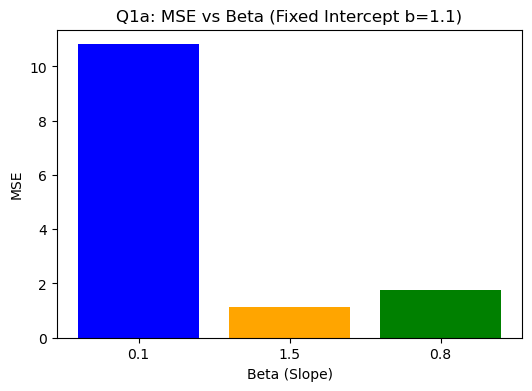

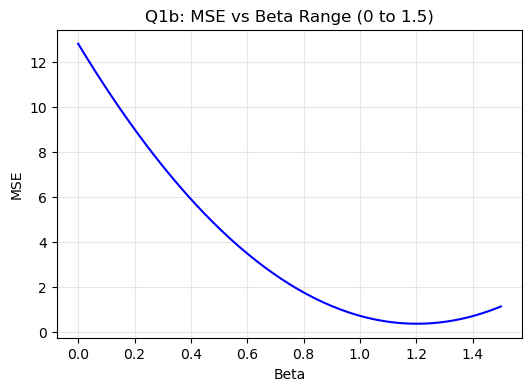

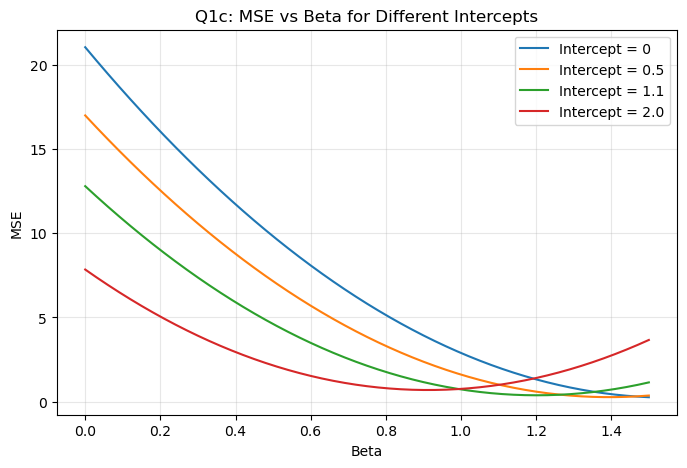

Q1d. Scikit-Learn Results:
Intercept (B0): -0.0356
Slope (B1): 1.5671
MSE: 0.2337


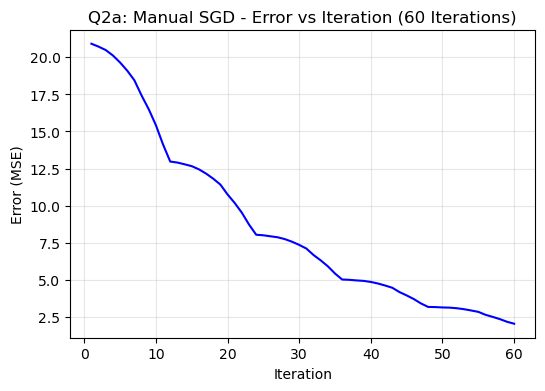


Q2b. Scikit-learn SGD Results (5 epochs):
Intercept (B0): 1.9548, Slope (B1): 0.6958


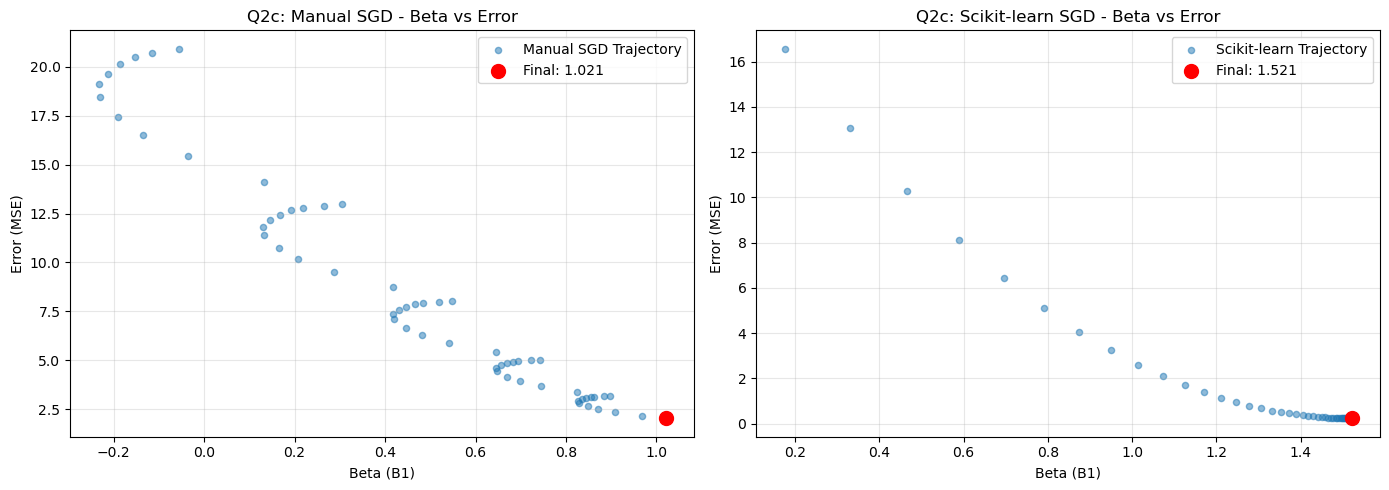

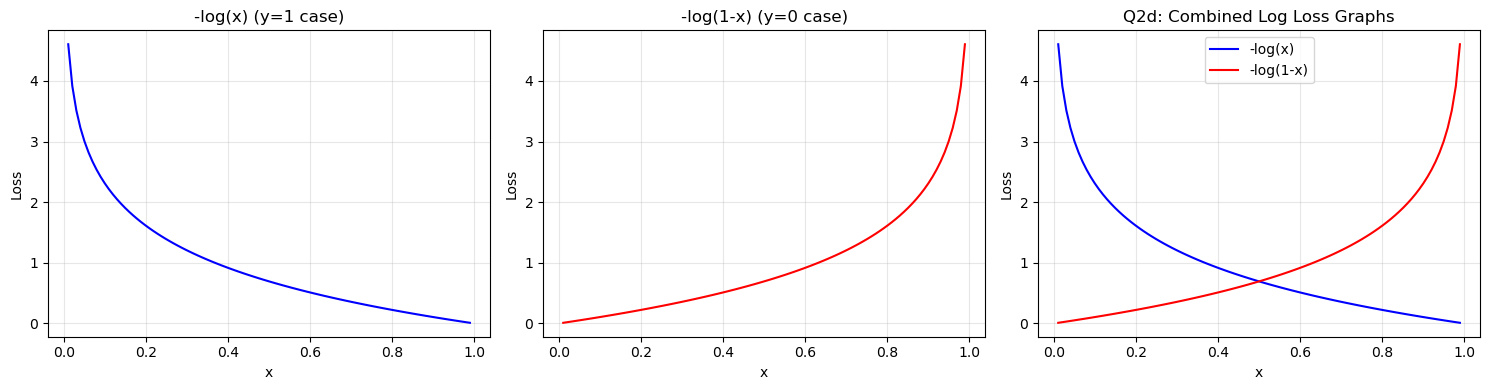

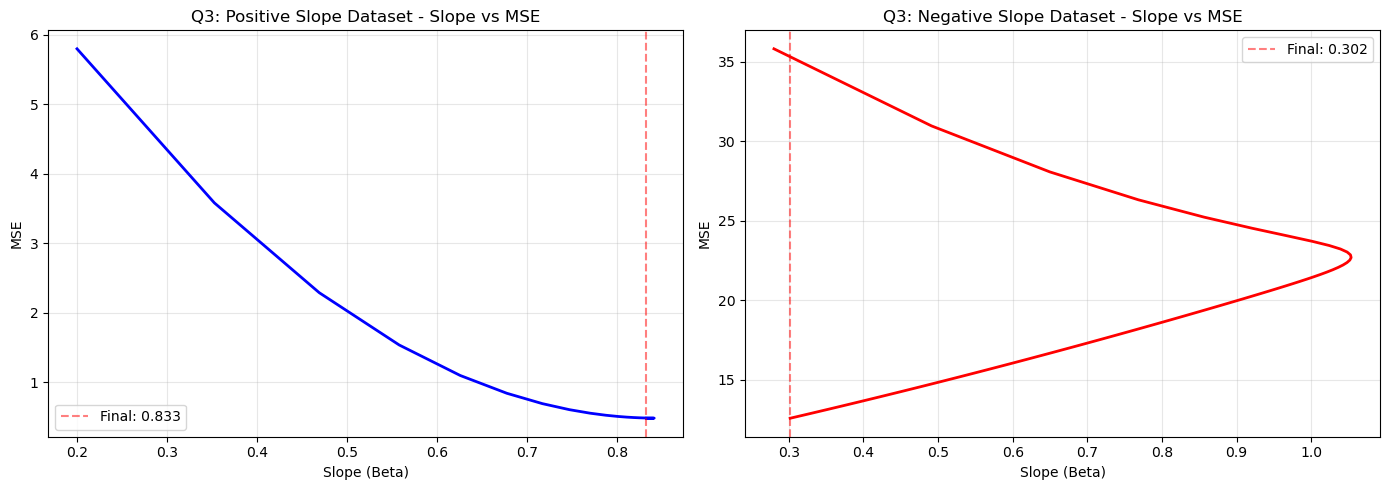

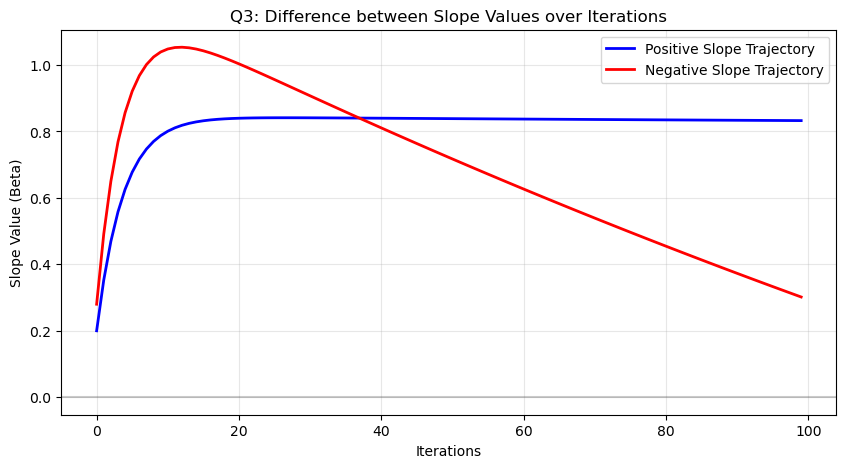

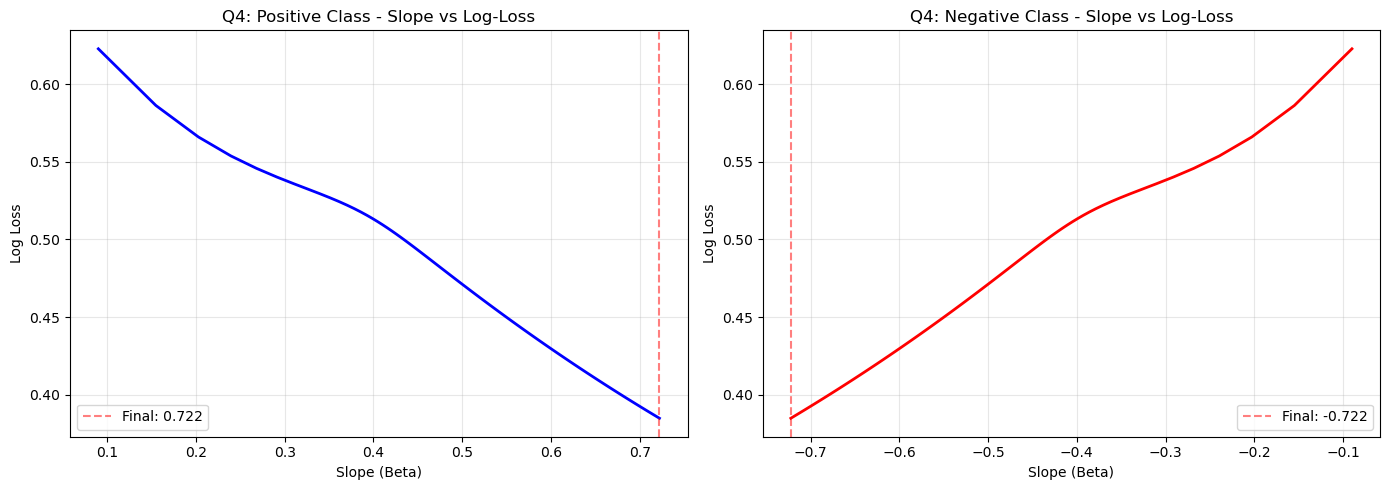

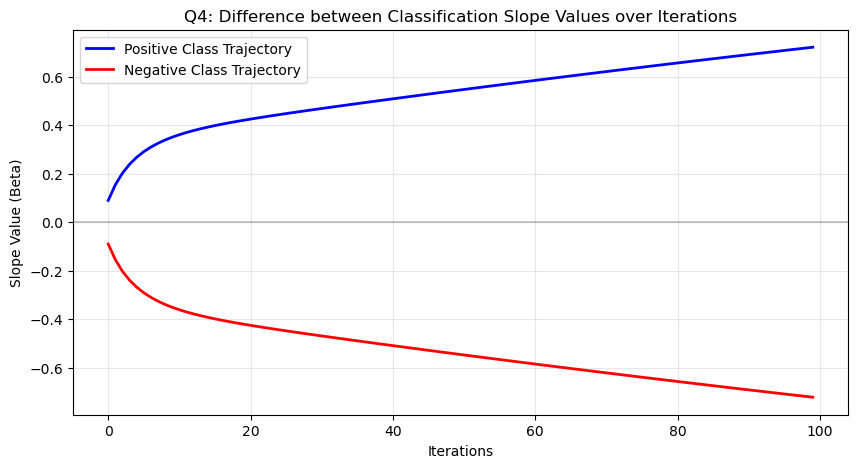

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Q1: Simple Linear Regression with Salary_Data
# ============================================================================

# Note: Using dataset as provided in the assignment
data = {
    'experience': [1.2, 1.5, 1.9, 2.2, 2.4, 2.5, 2.8, 3.1, 3.3, 3.7, 4.2, 4.4],
    'salary': [1.7, 2.4, 2.3, 3.1, 3.7, 4.2, 4.4, 6.1, 5.4, 5.7, 6.4, 6.2]
}
df = pd.DataFrame(data)
df.to_csv('Salary_Data.csv', index=False)

X = df['experience'].values
y = df['salary'].values

# a. Check for beta = 0.1, 1.5, 0.8 with fixed intercept b = 1.1
b0 = 1.1
betas_a = [0.1, 1.5, 0.8]
mse_a = [mean_squared_error(y, b0 + b * X) for b in betas_a]

plt.figure(figsize=(6, 4))
plt.bar([str(b) for b in betas_a], mse_a, color=['blue', 'orange', 'green'])
plt.xlabel('Beta (Slope)')
plt.ylabel('MSE')
plt.title('Q1a: MSE vs Beta (Fixed Intercept b=1.1)')
plt.show()

# b. Try beta between 0 to 1.5 with increment 0.01, fixed intercept
betas_b = np.arange(0, 1.51, 0.01)
mse_b = [mean_squared_error(y, b0 + b * X) for b in betas_b]

plt.figure(figsize=(6, 4))
plt.plot(betas_b, mse_b, 'b-')
plt.xlabel('Beta')
plt.ylabel('MSE')
plt.title('Q1b: MSE vs Beta Range (0 to 1.5)')
plt.grid(True, alpha=0.3)
plt.show()

# c. Try different values of intercept for slope beta between 0 to 1.5
intercepts = [0, 0.5, 1.1, 2.0]
plt.figure(figsize=(8, 5))
for b_int in intercepts:
    mse_c = [mean_squared_error(y, b_int + b * X) for b in betas_b]
    plt.plot(betas_b, mse_c, label=f'Intercept = {b_int}')
plt.xlabel('Beta')
plt.ylabel('MSE')
plt.title('Q1c: MSE vs Beta for Different Intercepts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# d. Use scikit-learn and compare results
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
y_pred_sklearn = model.predict(X.reshape(-1, 1))
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

print("Q1d. Scikit-Learn Results:")
print(f"Intercept (B0): {model.intercept_:.4f}")
print(f"Slope (B1): {model.coef_[0]:.4f}")
print(f"MSE: {mse_sklearn:.4f}")


# ============================================================================
# Q2: Stochastic Gradient Descent
# ============================================================================

# Scale features for better SGD convergence
X_scaled = (X - X.mean()) / X.std()

# 60 iterations total (5 epochs * 12 samples = 60)
epochs = 5
b0, b1 = 0.0, 0.0
lr = 0.01

b1_hist_man, mse_hist_man = [], []

for epoch in range(epochs):
    for i in range(len(X_scaled)):
        # Calculate prediction and error
        y_pred = b0 + b1 * X_scaled[i]
        error = y[i] - y_pred
        
        # Update weights
        b0 = b0 - lr * (-2 * error)
        b1 = b1 - lr * (-2 * error * X_scaled[i])
        
        # Track history
        b1_hist_man.append(b1)
        # FIXED: Calculate MSE after update with current b0, b1
        y_pred_all = b0 + b1 * X_scaled
        mse_hist_man.append(mean_squared_error(y, y_pred_all))

# a. Plot graph of error vs iteration
plt.figure(figsize=(6, 4))
plt.plot(range(1, 61), mse_hist_man, 'b-')
plt.xlabel('Iteration')
plt.ylabel('Error (MSE)')
plt.title('Q2a: Manual SGD - Error vs Iteration (60 Iterations)')
plt.grid(True, alpha=0.3)
plt.show()

# b. Use scikit-learn for 60 iterations (5 epochs)
sgd = SGDRegressor(max_iter=5, learning_rate='constant', eta0=0.01, random_state=42)
sgd.fit(X_scaled.reshape(-1, 1), y)
print("\nQ2b. Scikit-learn SGD Results (5 epochs):")
print(f"Intercept (B0): {sgd.intercept_[0]:.4f}, Slope (B1): {sgd.coef_[0]:.4f}")

# c. FIXED: Plot beta vs error using actual scikit-learn vs manual approach
# Run SGDRegressor and track its trajectory
b1_sklearn_traj, mse_sklearn_traj = [], []
sgd_temp = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01, random_state=42, warm_start=True)

# Initialize with first iteration
sgd_temp.partial_fit(X_scaled.reshape(-1, 1), y)
b1_sklearn_traj.append(sgd_temp.coef_[0])
y_pred = sgd_temp.predict(X_scaled.reshape(-1, 1))
mse_sklearn_traj.append(mean_squared_error(y, y_pred))

# Continue for remaining iterations
for i in range(59):
    sgd_temp.partial_fit(X_scaled.reshape(-1, 1), y)
    b1_sklearn_traj.append(sgd_temp.coef_[0])
    y_pred = sgd_temp.predict(X_scaled.reshape(-1, 1))
    mse_sklearn_traj.append(mean_squared_error(y, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Manual approach
axes[0].scatter(b1_hist_man, mse_hist_man, alpha=0.5, s=20, label='Manual SGD Trajectory')
axes[0].scatter([b1_hist_man[-1]], [mse_hist_man[-1]], color='red', s=100, zorder=5, label=f'Final: {b1_hist_man[-1]:.3f}')
axes[0].set_xlabel('Beta (B1)')
axes[0].set_ylabel('Error (MSE)')
axes[0].set_title('Q2c: Manual SGD - Beta vs Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scikit-learn approach (ACTUAL sklearn implementation)
axes[1].scatter(b1_sklearn_traj, mse_sklearn_traj, alpha=0.5, s=20, label='Scikit-learn Trajectory')
axes[1].scatter([b1_sklearn_traj[-1]], [mse_sklearn_traj[-1]], color='red', s=100, zorder=5, label=f'Final: {b1_sklearn_traj[-1]:.3f}')
axes[1].set_xlabel('Beta (B1)')
axes[1].set_ylabel('Error (MSE)')
axes[1].set_title('Q2c: Scikit-learn SGD - Beta vs Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# d. Plot log loss graphs
x_vals = np.linspace(0.01, 0.99, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# y=1 case: -log(x)
axes[0].plot(x_vals, -np.log(x_vals), 'b-')
axes[0].set_title('-log(x) (y=1 case)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# y=0 case: -log(1-x)
axes[1].plot(x_vals, -np.log(1 - x_vals), 'r-')
axes[1].set_title('-log(1-x) (y=0 case)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

# Combined
axes[2].plot(x_vals, -np.log(x_vals), 'b-', label='-log(x)')
axes[2].plot(x_vals, -np.log(1 - x_vals), 'r-', label='-log(1-x)')
axes[2].set_title('Q2d: Combined Log Loss Graphs')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# Q3: Simple Linear Regression with Gradient Descent - Positive/Negative Slope
# ============================================================================

def slr_gd(X, y, epochs=100, lr=0.01):
    """Simple Linear Regression using Gradient Descent"""
    b0, b1 = 0, 0
    m = len(X)
    b1_hist, mse_hist = [], []
    for epoch in range(epochs):
        y_pred = b0 + b1 * X
        # Calculate gradients
        grad_b0 = (-2/m) * np.sum(y - y_pred)
        grad_b1 = (-2/m) * np.sum((y - y_pred) * X)
        # Update
        b0 -= lr * grad_b0
        b1 -= lr * grad_b1
        # FIXED: Calculate MSE after update
        y_pred_new = b0 + b1 * X
        b1_hist.append(b1)
        mse_hist.append(mean_squared_error(y, y_pred_new))
    return b1_hist, mse_hist

# Data from Q3
x_pos, y_pos = np.array([1, 2, 4, 3, 5]), np.array([1, 3, 3, 2, 5])  # Positive slope
x_neg, y_neg = np.array([1, 2, 3, 4, 5]), np.array([10, 8, 6, 4, 2])  # Negative slope

b1_pos, mse_pos = slr_gd(x_pos, y_pos)
b1_neg, mse_neg = slr_gd(x_neg, y_neg)

# Plot: Slope vs MSE for both cases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(b1_pos, mse_pos, 'b-', linewidth=2)
axes[0].set_title('Q3: Positive Slope Dataset - Slope vs MSE')
axes[0].set_xlabel('Slope (Beta)')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=b1_pos[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {b1_pos[-1]:.3f}')
axes[0].legend()

axes[1].plot(b1_neg, mse_neg, 'r-', linewidth=2)
axes[1].set_title('Q3: Negative Slope Dataset - Slope vs MSE')
axes[1].set_xlabel('Slope (Beta)')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=b1_neg[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {b1_neg[-1]:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot: Slope values at different iterations
plt.figure(figsize=(10, 5))
plt.plot(range(100), b1_pos, 'b-', linewidth=2, label='Positive Slope Trajectory')
plt.plot(range(100), b1_neg, 'r-', linewidth=2, label='Negative Slope Trajectory')
plt.xlabel('Iterations')
plt.ylabel('Slope Value (Beta)')
plt.title('Q3: Difference between Slope Values over Iterations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.show()


# ============================================================================
# Q4: Logistic Regression with Gradient Descent - Positive/Negative Class
# ============================================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_reg_gd(X, y, epochs=100, lr=0.1):
    """Logistic Regression using Gradient Descent"""
    b0, b1 = 0, 0
    m = len(X)
    b1_hist, loss_hist = [], []
    for epoch in range(epochs):
        y_pred = sigmoid(b0 + b1 * X)
        # Gradient descent updates
        grad_b0 = (1/m) * np.sum(y_pred - y)
        grad_b1 = (1/m) * np.sum((y_pred - y) * X)
        b0 -= lr * grad_b0
        b1 -= lr * grad_b1
        
        # FIXED: Calculate loss after update
        y_pred_new = sigmoid(b0 + b1 * X)
        p = np.clip(y_pred_new, 1e-15, 1 - 1e-15)
        loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        b1_hist.append(b1)
        loss_hist.append(loss)
    return b1_hist, loss_hist

# Data from Q4
x_pos_c, y_pos_c = np.array([1, 2, 3, 4, 5]), np.array([0, 0, 1, 1, 1])  # Positive class
x_neg_c, y_neg_c = np.array([1, 2, 3, 4, 5]), np.array([1, 1, 0, 0, 0])  # Negative class

b1_pos_c, loss_pos = log_reg_gd(x_pos_c, y_pos_c)
b1_neg_c, loss_neg = log_reg_gd(x_neg_c, y_neg_c)

# Plot: Slope vs Log-Loss for both cases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(b1_pos_c, loss_pos, 'b-', linewidth=2)
axes[0].set_title('Q4: Positive Class - Slope vs Log-Loss')
axes[0].set_xlabel('Slope (Beta)')
axes[0].set_ylabel('Log Loss')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=b1_pos_c[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {b1_pos_c[-1]:.3f}')
axes[0].legend()

axes[1].plot(b1_neg_c, loss_neg, 'r-', linewidth=2)
axes[1].set_title('Q4: Negative Class - Slope vs Log-Loss')
axes[1].set_xlabel('Slope (Beta)')
axes[1].set_ylabel('Log Loss')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=b1_neg_c[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {b1_neg_c[-1]:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot: Slope values at different iterations for classification
plt.figure(figsize=(10, 5))
plt.plot(range(100), b1_pos_c, 'b-', linewidth=2, label='Positive Class Trajectory')
plt.plot(range(100), b1_neg_c, 'r-', linewidth=2, label='Negative Class Trajectory')
plt.xlabel('Iterations')
plt.ylabel('Slope Value (Beta)')
plt.title('Q4: Difference between Classification Slope Values over Iterations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.show()



## q2

## q3

## q4